In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
df = pd.read_csv(
    "/content/Telco_Customer_Churn_Dataset  (3).csv"
)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df["tenure"] = pd.to_numeric(df["tenure"], errors="coerce")

In [7]:
def tenure_category(tenure):
    if tenure <= 12:
        return "0-12 months"
    elif tenure <= 36:
        return "13-36 months"
    else:
        return "37+ months"

df["tenure_category"] = df["tenure"].apply(tenure_category)

In [8]:
tenure_counts = df["tenure_category"].value_counts()
tenure_counts

,count
tenure_category,
37+ months,3001
0-12 months,2186
13-36 months,1856


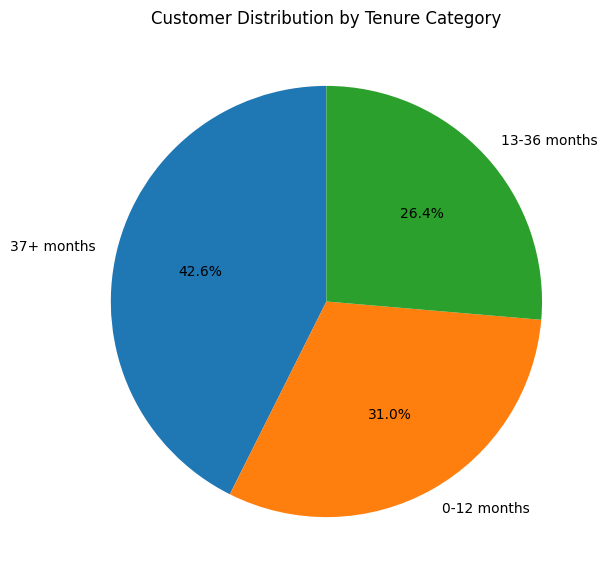

In [9]:
plt.figure(figsize=(7, 7))

plt.pie(
    tenure_counts,
    labels=tenure_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Distribution by Tenure Category")

plt.show()

In [11]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'tenure_category'],
      dtype='object')

In [12]:
average_charges = df.groupby("tenure_category")["MonthlyCharges"].mean()

average_charges

,MonthlyCharges
tenure_category,
0-12 months,56.097781
13-36 months,63.248195
37+ months,72.008730


In [14]:
fig = px.bar(
    average_charges.reset_index(),
    x="tenure_category",
    y="MonthlyCharges",
    title="Average Monthly Charges by Tenure Category",
    labels={
        "tenure_category": "Tenure Category",
        "MonthlyCharges": "Average Monthly Charges"
    },
    text="MonthlyCharges"
)

fig.show()

In [15]:
highest_category = average_charges.idxmax()
highest_value = average_charges.max()

print("Highest category:", highest_category)
print("Highest average monthly charge:", highest_value)

Highest category: 37+ months
Highest average monthly charge: 72.00873042319228


In [16]:
fig = px.bar(
    average_charges.reset_index(),
    x="tenure_category",
    y="MonthlyCharges",
    title="Average Monthly Charges by Tenure Category",
    labels={
        "tenure_category": "Tenure Category",
        "MonthlyCharges": "Average Monthly Charges"
    },
    text="MonthlyCharges"
)

fig.add_annotation(
    x=highest_category,
    y=highest_value,
    text=f"Highest: {highest_value:.2f}",
    showarrow=True,
    arrowhead=2
)

fig.show()

In [17]:
print("Highest:", average_charges.idxmax(), average_charges.max())
print("Lowest:", average_charges.idxmin(), average_charges.min())

Highest: 37+ months 72.00873042319228
Lowest: 0-12 months 56.0977813357731
